# Queue Imbalance: Raw vs. Filtered vs. Shock, by Normalization Type

Plots the out-of-sample AUC for three versions of queue imbalance, across
all 5 prediction horizons, against the null-model baseline of 0.500
(Gould & Bonart 2015, Section 5.4) - with a **separate set of plots for
each normalization type** (ZScore / MinMax / DecPre), since they behave
differently and shouldn't be averaged together.

| Signal | What it is |
|---|---|
| **raw** | Unfiltered imbalance ratio, straight from observed quantities (Gould & Bonart's own definition) |
| **filtered** | Kalman/IMM-smoothed imbalance - the filter's trend estimate |
| **shock** *(formerly "residual")* | `raw - filtered` - the instantaneous deviation/turbulence the filter treats as noise and discards |

Set `CSV_PATH` below to point at your actual results file.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

CSV_PATH = "summary_v2.csv"  # <- change this to your actual output file

HORIZON_ORDER = ["k=10", "k=20", "k=30", "k=50", "k=100"]
NULL_AUC = 0.5

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} raw rows from {CSV_PATH}")

n_errors = (df["status"] != "ok").sum() if "status" in df.columns else 0
if n_errors:
    print(f"WARNING: {n_errors} row(s) have status != 'ok' - excluded.")
    df = df[df["status"] == "ok"].copy()

# Dedup: earlier/interrupted runs can leave stale duplicate rows for the
# same (fold, horizon). Keep the LAST occurrence, which is the most
# recent (and correct, post-fix) computation.
before = len(df)
df = df.drop_duplicates(subset=["fold", "horizon"], keep="last")
if before != len(df):
    print(f"Dropped {before - len(df)} duplicate/stale (fold, horizon) row(s).")

# Extract normalization type from the fold name, e.g. "Auction_ZScore_CF_3" -> "ZScore"
df["norm"] = df["fold"].str.extract(r"Auction_(\w+?)_CF")
norms_found = sorted(df["norm"].dropna().unique())
print(f"Normalization types found: {norms_found}")

df["horizon"] = pd.Categorical(df["horizon"], categories=HORIZON_ORDER, ordered=True)
df = df.sort_values("horizon")

SIGNAL_COLUMNS = {"raw_auc": "raw", "filtered_auc": "filtered", "residual_auc": "shock"}
colors = {"raw": "#4C72B0", "filtered": "#55A868", "shock": "#C44E52"}
markers = {"raw": "o", "filtered": "s", "shock": "^"}

for norm in norms_found:
    n_folds = df[df["norm"] == norm]["fold"].nunique()
    print(f"  {norm}: {n_folds} fold(s)")

Loaded 185 raw rows from summary_v2.csv
Dropped 50 duplicate/stale (fold, horizon) row(s).
Normalization types found: ['DecPre', 'MinMax', 'ZScore']
  DecPre: 9 fold(s)
  MinMax: 9 fold(s)
  ZScore: 9 fold(s)


## Per-normalization AUC comparison

One figure per dataset (ZScore / MinMax / DecPre), each showing raw vs.
filtered vs. shock across all 5 horizons, averaged across that dataset's
folds, with the 0.500 null baseline for reference.

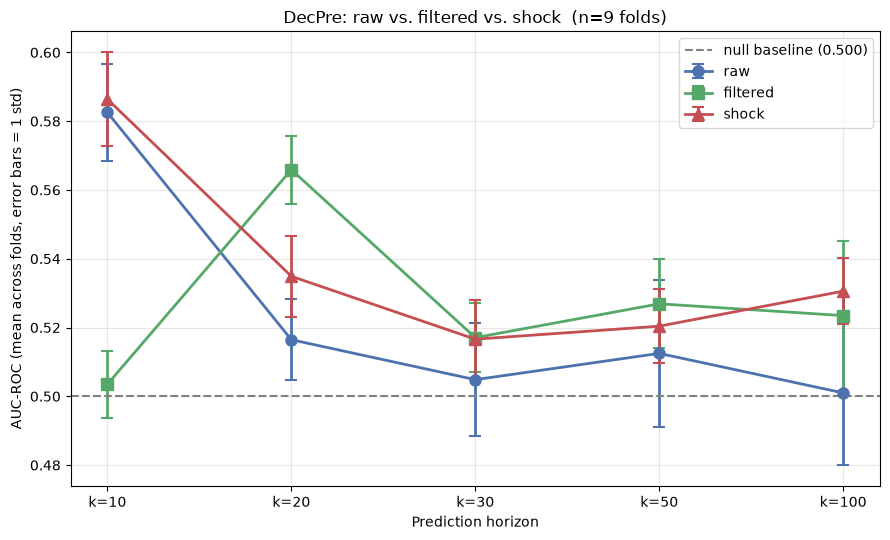


--- DecPre summary table ---

raw:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.583    0.014        9
k=20        0.516    0.012        9
k=30        0.505    0.016        9
k=50        0.512    0.021        9
k=100       0.501    0.021        9

filtered:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.504    0.010        9
k=20        0.566    0.010        9
k=30        0.517    0.010        9
k=50        0.527    0.013        9
k=100       0.523    0.022        9

shock:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.586    0.014        9
k=20        0.535    0.012        9
k=30        0.517    0.011        9
k=50        0.520    0.011        9
k=100       0.531    0.010        9



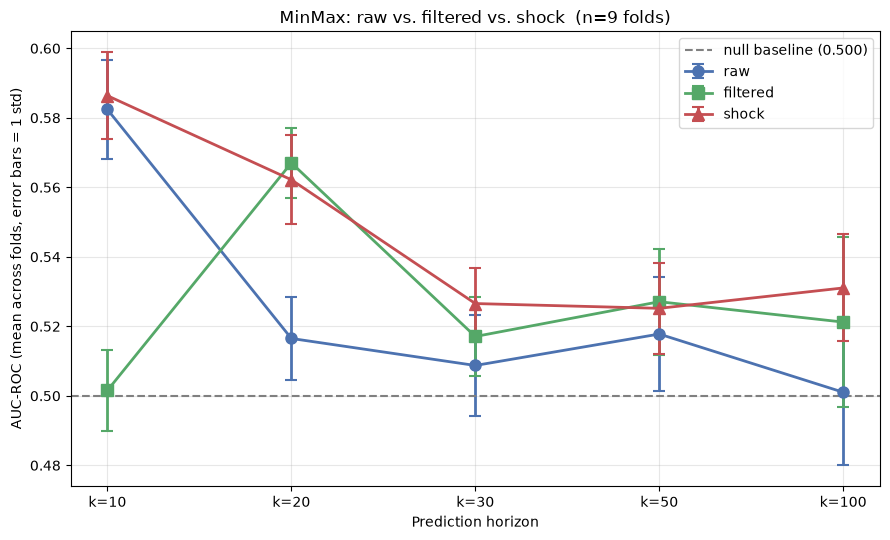


--- MinMax summary table ---

raw:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.582    0.014        9
k=20        0.517    0.012        9
k=30        0.509    0.014        9
k=50        0.518    0.016        9
k=100       0.501    0.021        9

filtered:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.502    0.012        9
k=20        0.567    0.010        9
k=30        0.517    0.011        9
k=50        0.527    0.015        9
k=100       0.521    0.024        9

shock:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.586    0.013        9
k=20        0.562    0.013        9
k=30        0.527    0.010        9
k=50        0.525    0.013        9
k=100       0.531    0.015        9



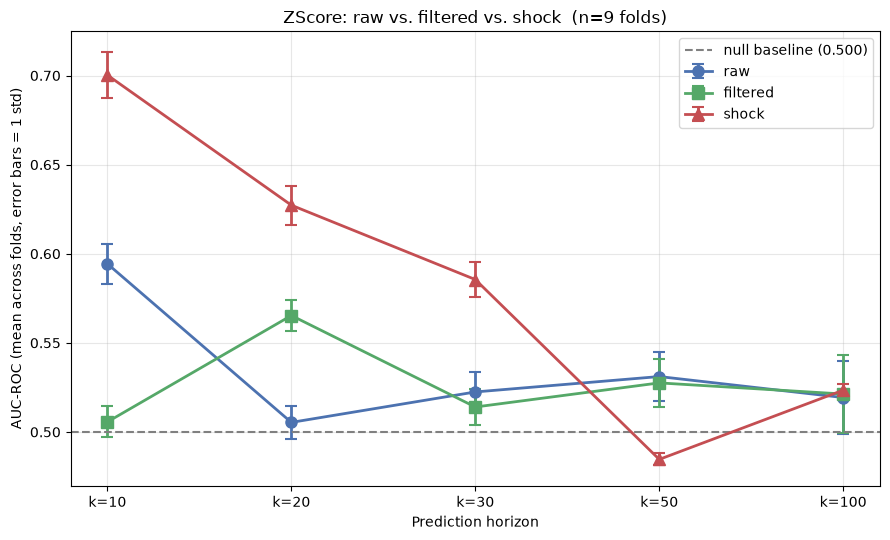


--- ZScore summary table ---

raw:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.594    0.011        9
k=20        0.505    0.009        9
k=30        0.522    0.011        9
k=50        0.531    0.014        9
k=100       0.519    0.021        9

filtered:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.506    0.009        9
k=20        0.565    0.009        9
k=30        0.514    0.010        9
k=50        0.528    0.013        9
k=100       0.521    0.022        9

shock:
         mean_auc  std_auc  n_folds
horizon                            
k=10        0.700    0.013        9
k=20        0.627    0.011        9
k=30        0.586    0.010        9
k=50        0.485    0.003        9
k=100       0.523    0.003        9



In [8]:
def summarize(sub, col):
    g = sub.groupby("horizon", observed=True)[col]
    return pd.DataFrame({"mean_auc": g.mean(), "std_auc": g.std(), "n_folds": g.count()})

x = np.arange(len(HORIZON_ORDER))

for norm in norms_found:
    sub = df[df["norm"] == norm]
    n_folds = sub["fold"].nunique()

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for col, label in SIGNAL_COLUMNS.items():
        s = summarize(sub, col).reindex(HORIZON_ORDER)
        ax.errorbar(x, s["mean_auc"], yerr=s["std_auc"], label=label,
                    color=colors[label], marker=markers[label], markersize=8,
                    linewidth=2, capsize=4, capthick=1.5)

    ax.axhline(NULL_AUC, color="gray", linestyle="--", linewidth=1.5, label="null baseline (0.500)")
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZON_ORDER)
    ax.set_xlabel("Prediction horizon")
    ax.set_ylabel("AUC-ROC (mean across folds, error bars = 1 std)")
    ax.set_title(f"{norm}: raw vs. filtered vs. shock  (n={n_folds} folds)")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"auc_comparison_{norm}.png", dpi=150)
    plt.show()

    print(f"\n--- {norm} summary table ---")
    for col, label in SIGNAL_COLUMNS.items():
        print(f"\n{label}:")
        print(summarize(sub, col).reindex(HORIZON_ORDER).round(3))
    print("\n" + "="*70)

## Per-normalization consistency: % of folds beating the null baseline

A high mean AUC hiding low consistency (only a couple of folds ran hot)
is a different, weaker claim than a signal that beats 0.5 on almost every
fold. Shown separately per dataset.

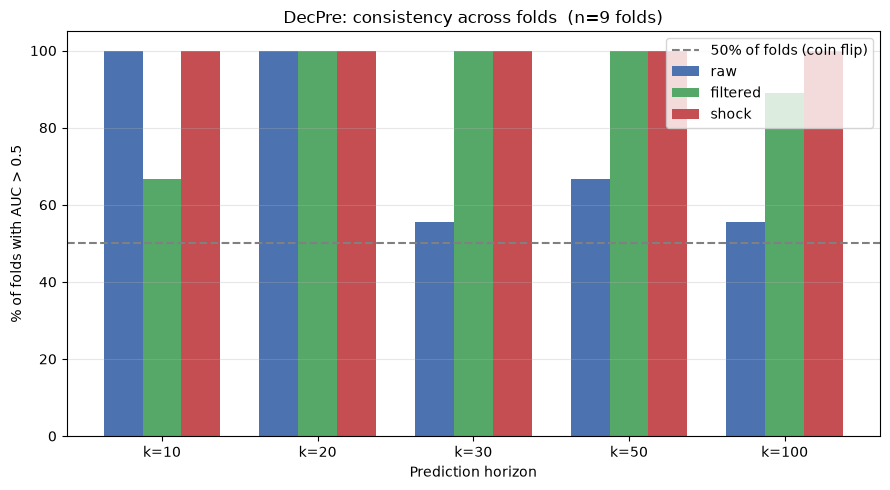

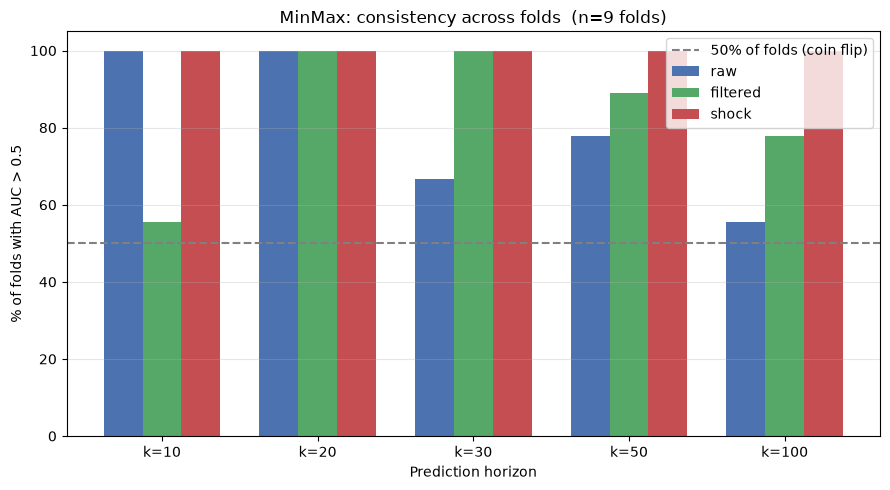

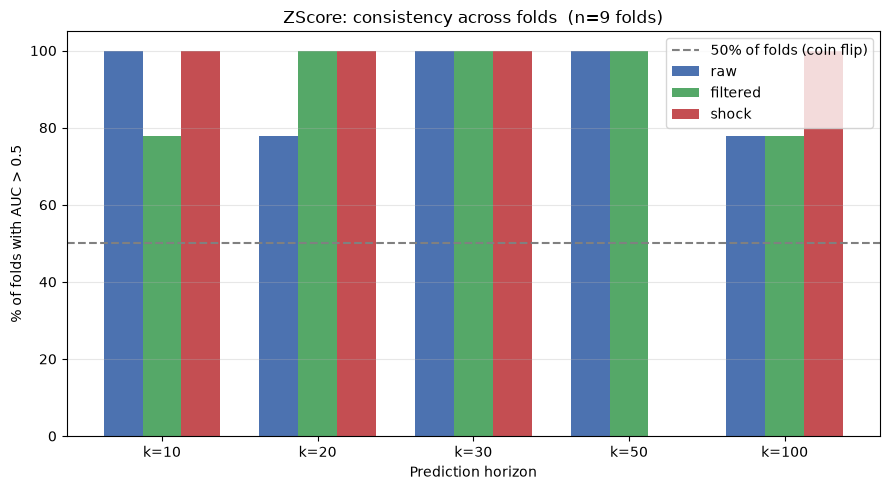

In [9]:
for norm in norms_found:
    sub = df[df["norm"] == norm]
    n_folds = sub["fold"].nunique()

    fig, ax = plt.subplots(figsize=(9, 5))
    width = 0.25
    for i, (col, label) in enumerate(SIGNAL_COLUMNS.items()):
        pct = sub.groupby("horizon", observed=True)[col].apply(lambda v: (v > NULL_AUC).mean() * 100)
        pct = pct.reindex(HORIZON_ORDER)
        ax.bar(x + (i - 1) * width, pct, width, label=label, color=colors[label])

    ax.axhline(50, color="gray", linestyle="--", linewidth=1.5, label="50% of folds (coin flip)")
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZON_ORDER)
    ax.set_xlabel("Prediction horizon")
    ax.set_ylabel("% of folds with AUC > 0.5")
    ax.set_title(f"{norm}: consistency across folds  (n={n_folds} folds)")
    ax.legend(loc="best")
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(f"consistency_{norm}.png", dpi=150)
    plt.show()

## Per-normalization boxplots: full fold-by-fold spread

Shows outlier folds and skew that mean +/- std can hide - one row of 5
subplots (one per horizon) per normalization type.

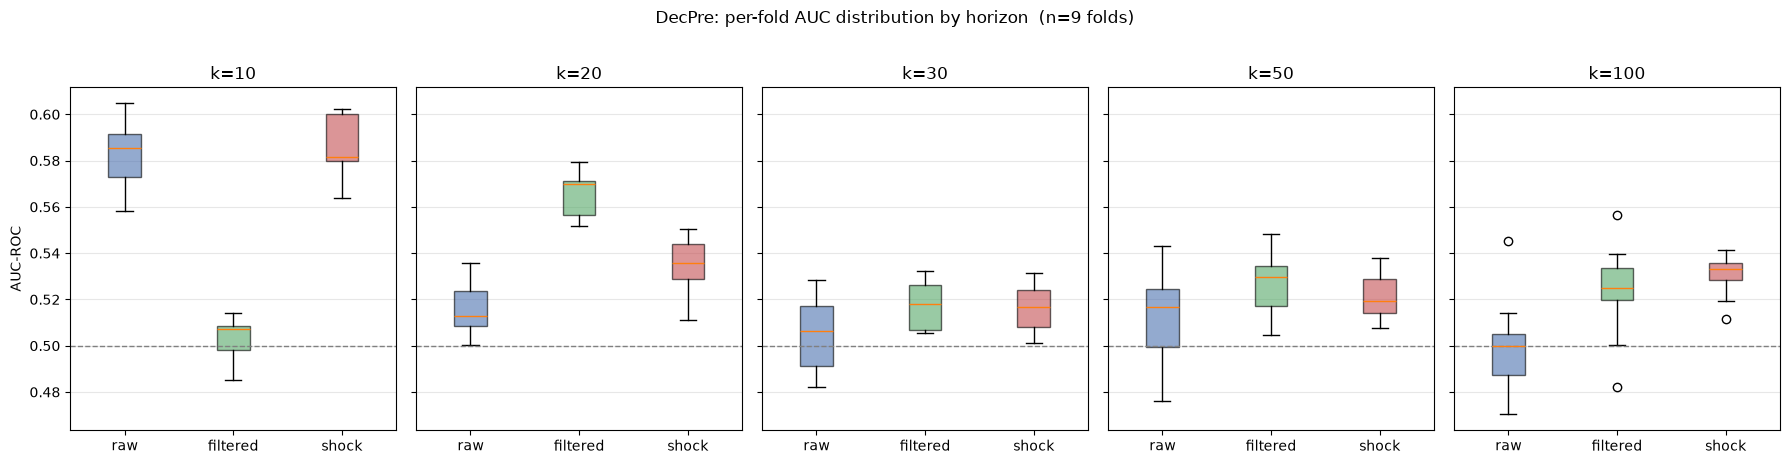

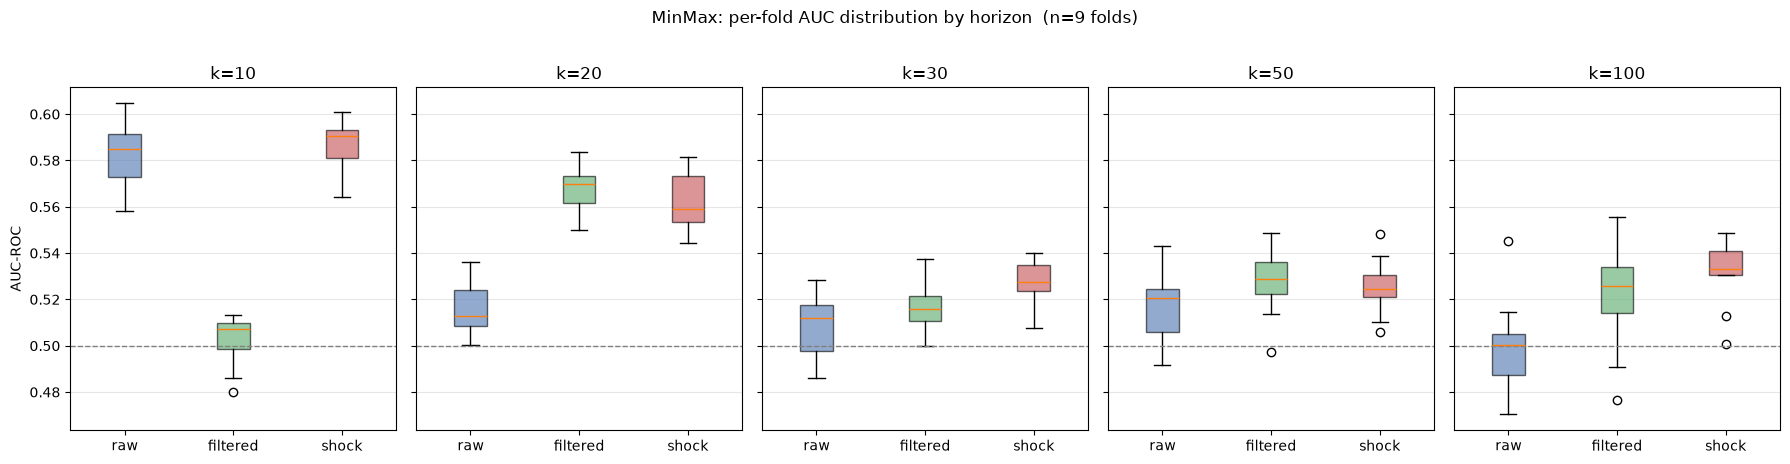

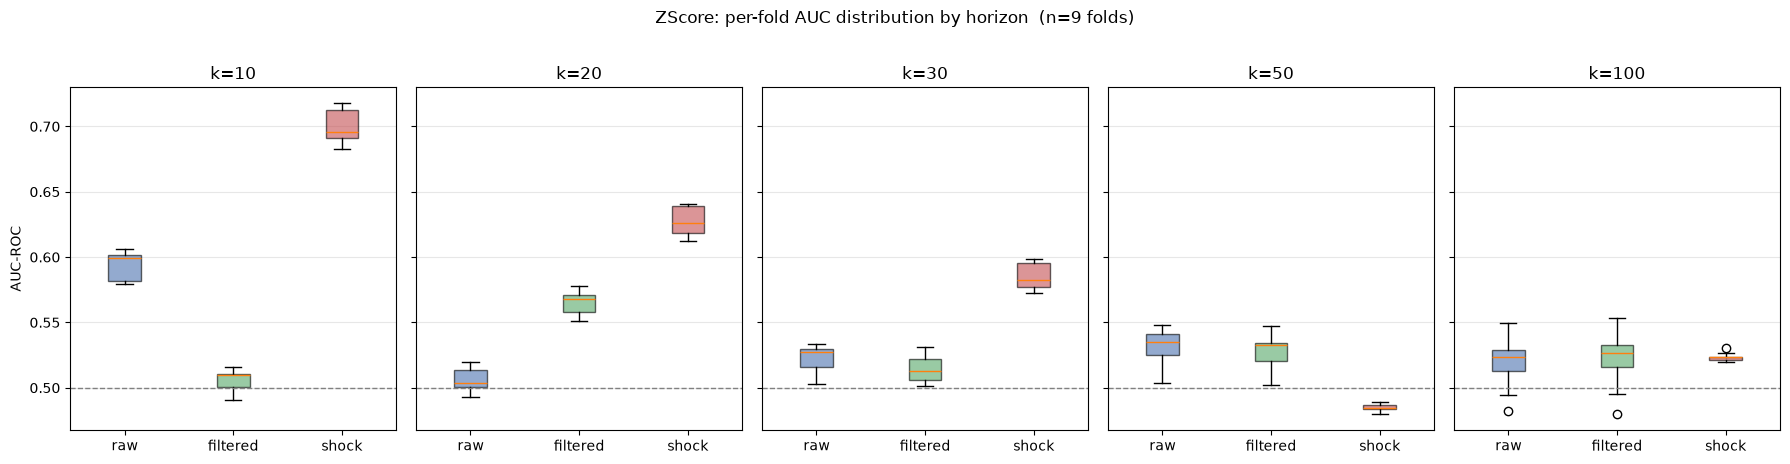

In [10]:
for norm in norms_found:
    sub = df[df["norm"] == norm]
    n_folds = sub["fold"].nunique()

    fig, axes = plt.subplots(1, len(HORIZON_ORDER), figsize=(18, 4.5), sharey=True)
    for ax, h in zip(axes, HORIZON_ORDER):
        hsub = sub[sub["horizon"] == h]
        data = [hsub["raw_auc"], hsub["filtered_auc"], hsub["residual_auc"]]
        bp = ax.boxplot(data, tick_labels=["raw", "filtered", "shock"], patch_artist=True)
        for patch, label in zip(bp["boxes"], ["raw", "filtered", "shock"]):
            patch.set_facecolor(colors[label])
            patch.set_alpha(0.6)
        ax.axhline(NULL_AUC, color="gray", linestyle="--", linewidth=1)
        ax.set_title(h)
        ax.grid(alpha=0.3, axis="y")

    axes[0].set_ylabel("AUC-ROC")
    plt.suptitle(f"{norm}: per-fold AUC distribution by horizon  (n={n_folds} folds)", y=1.02)
    plt.tight_layout()
    plt.savefig(f"boxplot_{norm}.png", dpi=150)
    plt.show()

## Bonus: all three normalizations side by side, shock signal only

Useful for spotting whether an effect is universal or specific to one
normalization scheme.

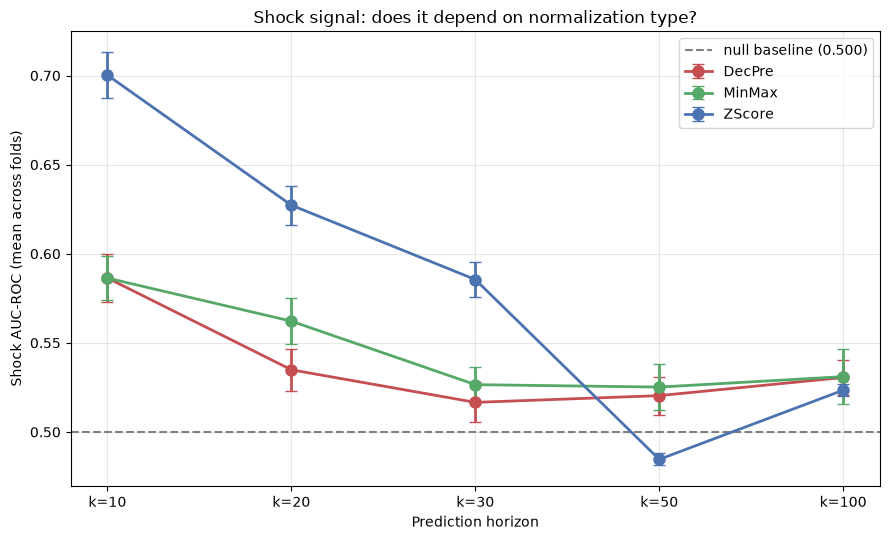

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
norm_colors = {"ZScore": "#4C72B0", "MinMax": "#55A868", "DecPre": "#C44E52"}

for norm in norms_found:
    sub = df[df["norm"] == norm]
    s = summarize(sub, "residual_auc").reindex(HORIZON_ORDER)
    color = norm_colors.get(norm, None)
    ax.errorbar(x, s["mean_auc"], yerr=s["std_auc"], label=norm,
                color=color, marker="o", markersize=8, linewidth=2, capsize=4)

ax.axhline(NULL_AUC, color="gray", linestyle="--", linewidth=1.5, label="null baseline (0.500)")
ax.set_xticks(x)
ax.set_xticklabels(HORIZON_ORDER)
ax.set_xlabel("Prediction horizon")
ax.set_ylabel("Shock AUC-ROC (mean across folds)")
ax.set_title("Shock signal: does it depend on normalization type?")
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("shock_by_normalization.png", dpi=150)
plt.show()